<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# ARIMA & SARIMA Lab

---


## Learning Objectives

### Core
- Test a time series for stationarity and determine the order of differencing (d)
- Use ACF/PACF plots to reason about AR and MA terms
- Fit an ARIMA model, forecast, and evaluate it
- Detect seasonality in a series and fit a SARIMA model
- Compare ARIMA vs. SARIMA performance on the same data and explain why one wins

### Target
- Use `auto_arima` to search for (p,d,q) and seasonal (P,D,Q,m) orders
- Produce forecasts with confidence intervals


## Scenario

You are a data scientist and were given the monthly airline passenger counts. Your manager wants a short-term forecast, and wants to know whether a simple ARIMA model is good enough or whether the extra complexity of SARIMA is worth it.

You will build both models on the same data and test which model is better.


## 0. Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(precision=4)
sns.set(font_scale=1.5)
plt.style.use('fivethirtyeight')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [16]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse
from pmdarima import auto_arima
# Ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")


<div class="alert alert-info"><strong>What is the below function?:</strong> Function for running the augmented Dickey-Fuller test (adfuller).</div>

In [3]:
def adf_test(series, title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")


<div class="alert alert-info"><strong>What is the below function?:</strong> plot ACF and PACF beside each other.</div>

In [4]:
def autocorr_plots(y, lags=None):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
    plot_acf(y, lags=lags, ax=ax[0])
    plot_pacf(y, lags=lags, ax=ax[1])
    return fig, ax


## 1. Load and inspect the data

This is historical monthly airline passenger counts (in thousands).

In [5]:
# 1a. Load the dataset, parsing the 'month' column as dates
df = pd.read_csv(r"C:\Users\jojah\GA_DSB\labs_projects\labs_projects\labs\TimeSer\airline_passengers.csv", parse_dates=['month'])
df.head()

,month,thousands_of_passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [6]:
# 1b. Set 'month' as an Index and set the frequency to Monthly-Start (use resamling).
df.set_index('month', inplace=True)
df = df.resample('MS').mean()
df.index.freq = 'MS'
df.head()

,thousands_of_passengers
month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


(144, 1)


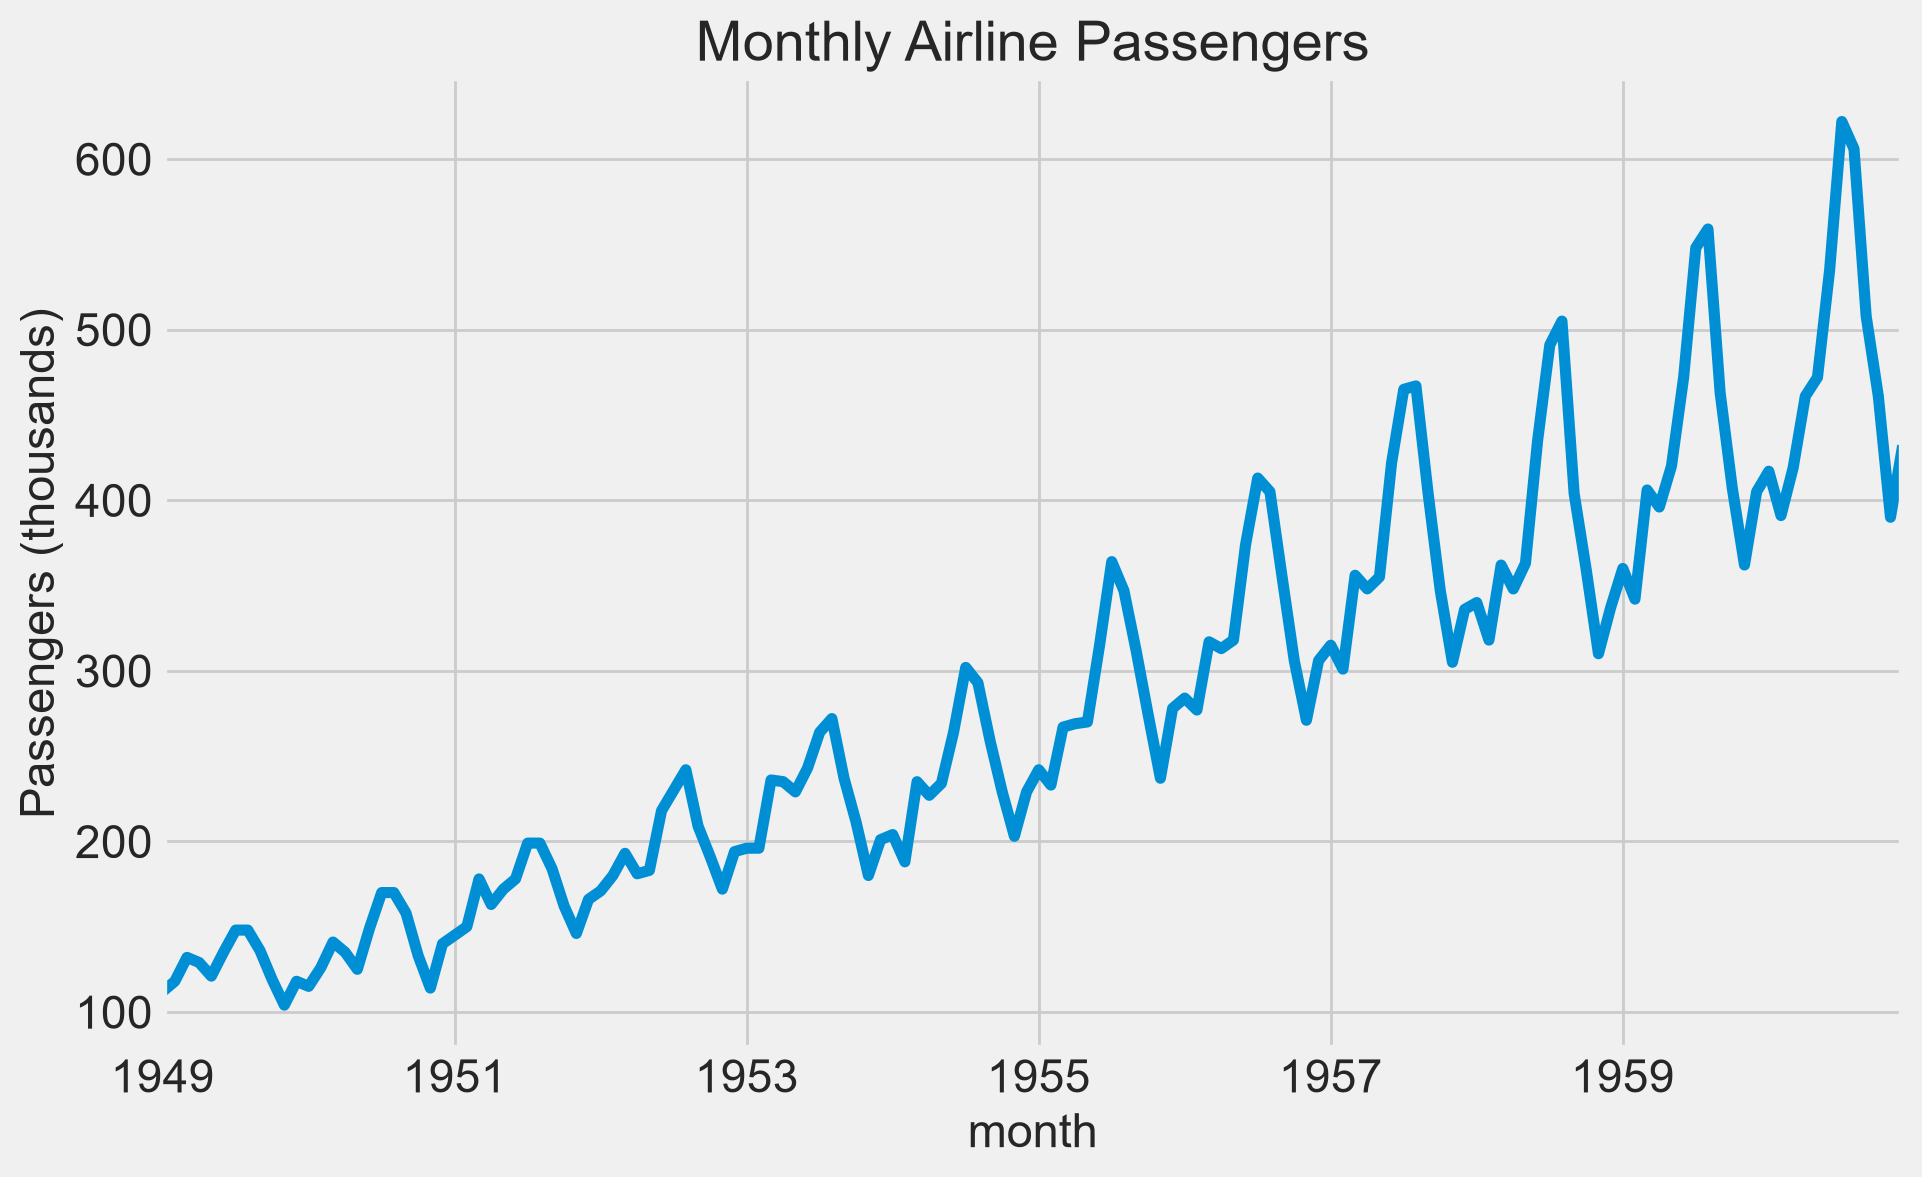

In [7]:
# 1c. Plot the full series and look at shape.
print(df.shape)
df['thousands_of_passengers'].plot(figsize=(10, 6), title='Monthly Airline Passengers')
plt.ylabel('Passengers (thousands)')
plt.show()

---
# Part A - ARIMA

We'll start simple: treat this as a general time series and build a non-seasonal ARIMA model. Follow the same workflow: 

> **Stationarity -> Differencing -> ACF/PACF -> Fit -> Evaluate**.


### A1. Check stationarity

In [8]:
# Run adf_test on the passenger series. Is it stationary?
adf_test(df['thousands_of_passengers'], title='Airline Passengers - Raw')

Augmented Dickey-Fuller Test: Airline Passengers - Raw
ADF test statistic        0.815369
p-value                   0.991880
# lags used              13.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


### A2. Difference until stationary

If the series isn't stationary, difference it (`.diff()`) and re-run the ADF test. Keep track of how many differences it took - that's your `d`.

In [9]:
# Difference once and re-test
adf_test(df['thousands_of_passengers'].diff(), title='Airline Passengers - 1st Difference')

Augmented Dickey-Fuller Test: Airline Passengers - 1st Difference
ADF test statistic       -2.829267
p-value                   0.054213
# lags used              12.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [10]:
# If needed, difference a second time and re-test
adf_test(df['thousands_of_passengers'].diff().diff(), title='Airline Passengers - 2nd Difference')

Augmented Dickey-Fuller Test: Airline Passengers - 2nd Difference
ADF test statistic     -1.638423e+01
p-value                 2.732892e-29
# lags used             1.100000e+01
# observations          1.300000e+02
critical value (1%)    -3.481682e+00
critical value (5%)    -2.884042e+00
critical value (10%)   -2.578770e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


**Write down your `d` value here:**

`d = `

### A3. ACF / PACF on the differenced series

Use `autocorr_plots()` on your *stationary* (differenced) series.

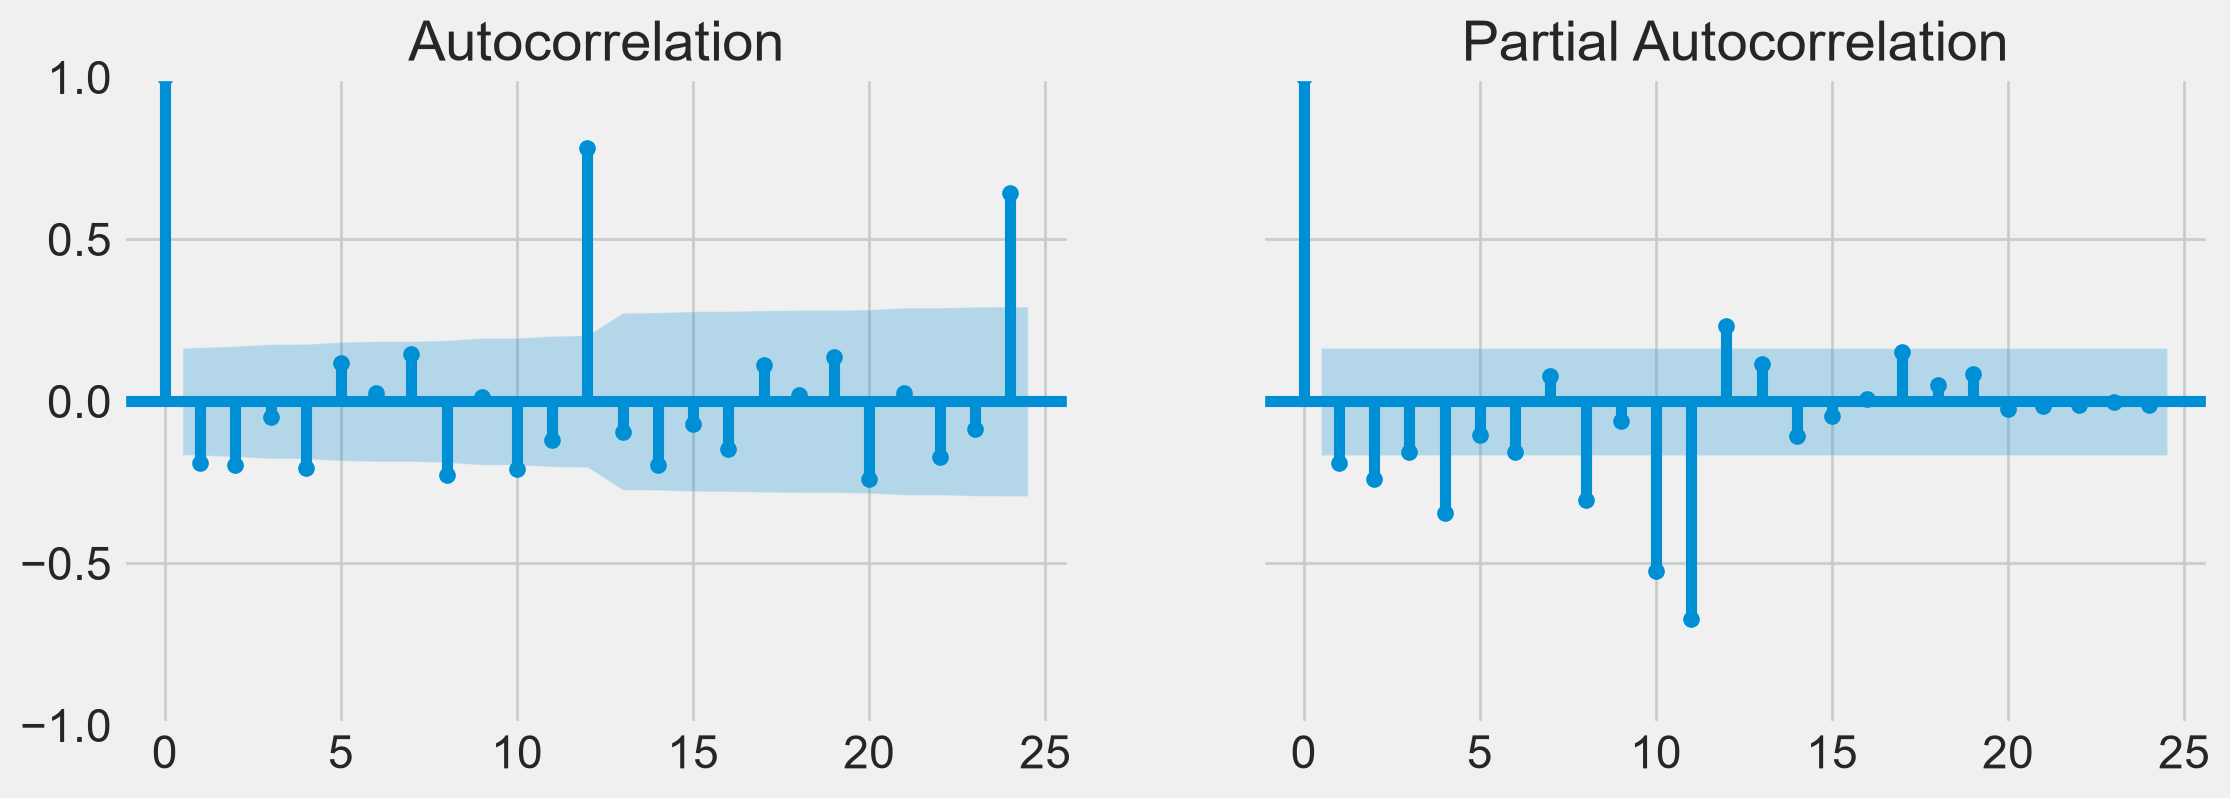

In [11]:
# Plot ACF and PACF on the differenced series, lags=24
autocorr_plots(df['thousands_of_passengers'].diff().diff().dropna(), lags=24);

**Based on the plots above, what would you guess for `p` and `q`?**

- p (AR terms): 
- q (MA terms): 

### A4. Confirm with auto_arima

Now check your manual guess against `auto_arima`. Keep `seasonal=False` as we are not modeling seasonality in Part A.

In [12]:
# Run auto_arima with seasonal=False and print the summary
auto_fit = auto_arima(df['thousands_of_passengers'],
                       start_p=0, start_q=0,
                       max_p=5, max_q=5,
                       d=None,
                       seasonal=False,
                       trace=True,
                       stepwise=True)
print(auto_fit.order)
auto_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1415.278, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1403.473, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1398.827, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1413.909, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1396.121, Time=0.26 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1398.386, Time=0.14 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1397.975, Time=0.09 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.49 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1394.683, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1397.258, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1401.852, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1378.338, Time=0.08 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1396.5

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:               SARIMAX(4, 1, 3)   Log Likelihood                -674.913
Date:                Thu, 13 Aug 2026   AIC                           1365.825
Time:                        15:56:10   BIC                           1389.528
Sample:                    01-01-1949   HQIC                          1375.457
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5582      0.117     -4.782      0.000      -0.787      -0.329
ar.L2          0.4935      0.113      4.375      0.000       0.272       0.715
ar.L3          0.1238      0.128      0.970      0.332      -0.126       0.374
ar.L4         -0.5213      0.085     -6.136      0.000      -0.688      -0.355
ma.L1          0.9069      0.094      9.657      0.000       0.723       1.091
ma.L2         -0.5590      0.145     -3.866      0.000      -0.842      -0.276
ma.L3         -0.7385      0.109     -6.778      0.000      -0.952      -0.525
sigma2       724.1727     85.616      8.458      0.000     556.369     891.976
===================================================================================
Ljung-Box (L1) (Q):                   0.37   Jarque-Bera (JB):                14.59
Prob(Q):                              0.54   Prob(JB):                         0.00
Heteroskedasticity (H):               5.66   Skew:                             0.74
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### A5. Train, Test, and Split

Hold out the last 12 months as your test set.

In [13]:
# Split into df_train (all but last 12 rows) and df_test (last 12 rows)
df_train = df.iloc[:-12]
df_test = df.iloc[-12:]

print(df_train.shape, df_test.shape)

(132, 1) (12, 1)


### A6. Fit the ARIMA model

Use the (p,d,q) order from A4.

In [17]:
# Fit ARIMA(p,d,q) on the training set
arima_order = auto_fit.order

arima_model = ARIMA(df_train['thousands_of_passengers'], order=arima_order)
arima_result = arima_model.fit()
arima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     thousands_of_passengers   No. Observations:                  132
Model:                      ARIMA(4, 1, 3)   Log Likelihood                -607.206
Date:                     Thu, 13 Aug 2026   AIC                           1230.412
Time:                             15:58:03   BIC                           1253.414
Sample:                         01-01-1949   HQIC                          1239.759
                              - 12-01-1959                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5693      0.115     -4.968      0.000      -0.794      -0.345
ar.L2          0.4828      0.123      3.935      0.000       0.242       0.723
ar.L3          0.1164      0.128      0.911      0.362      -0.134       0.367
ar.L4         -0.5331      0.084     -6.378      0.000      -0.697      -0.369
ma.L1          0.9304      0.103      8.994      0.000       0.728       1.133
ma.L2         -0.5541      0.151     -3.670      0.000      -0.850      -0.258
ma.L3         -0.7290      0.102     -7.155      0.000      -0.929      -0.529
sigma2       607.4737     76.263      7.965      0.000     458.000     756.947
===================================================================================
Ljung-Box (L1) (Q):                   0.20   Jarque-Bera (JB):                11.03
Prob(Q):                              0.65   Prob(JB):                         0.00
Heteroskedasticity (H):               4.40   Skew:                             0.69
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### A7. Predict on the test set

In [18]:
# Predict over the test period
start = len(df_train)
end = len(df_train) + len(df_test) - 1

arima_predictions = arima_result.predict(start, end).rename('ARIMA Predictions')
arima_predictions

1960-01-01    441.014245
1960-02-01    446.034164
1960-03-01    469.988829
1960-04-01    440.043181
1960-05-01    450.040026
1960-06-01    430.002104
1960-07-01    429.978876
1960-08-01    437.445821
1960-09-01    425.521802
1960-10-01    446.595420
1960-11-01    429.723135
1960-12-01    444.134242
Freq: MS, Name: ARIMA Predictions, dtype: float64

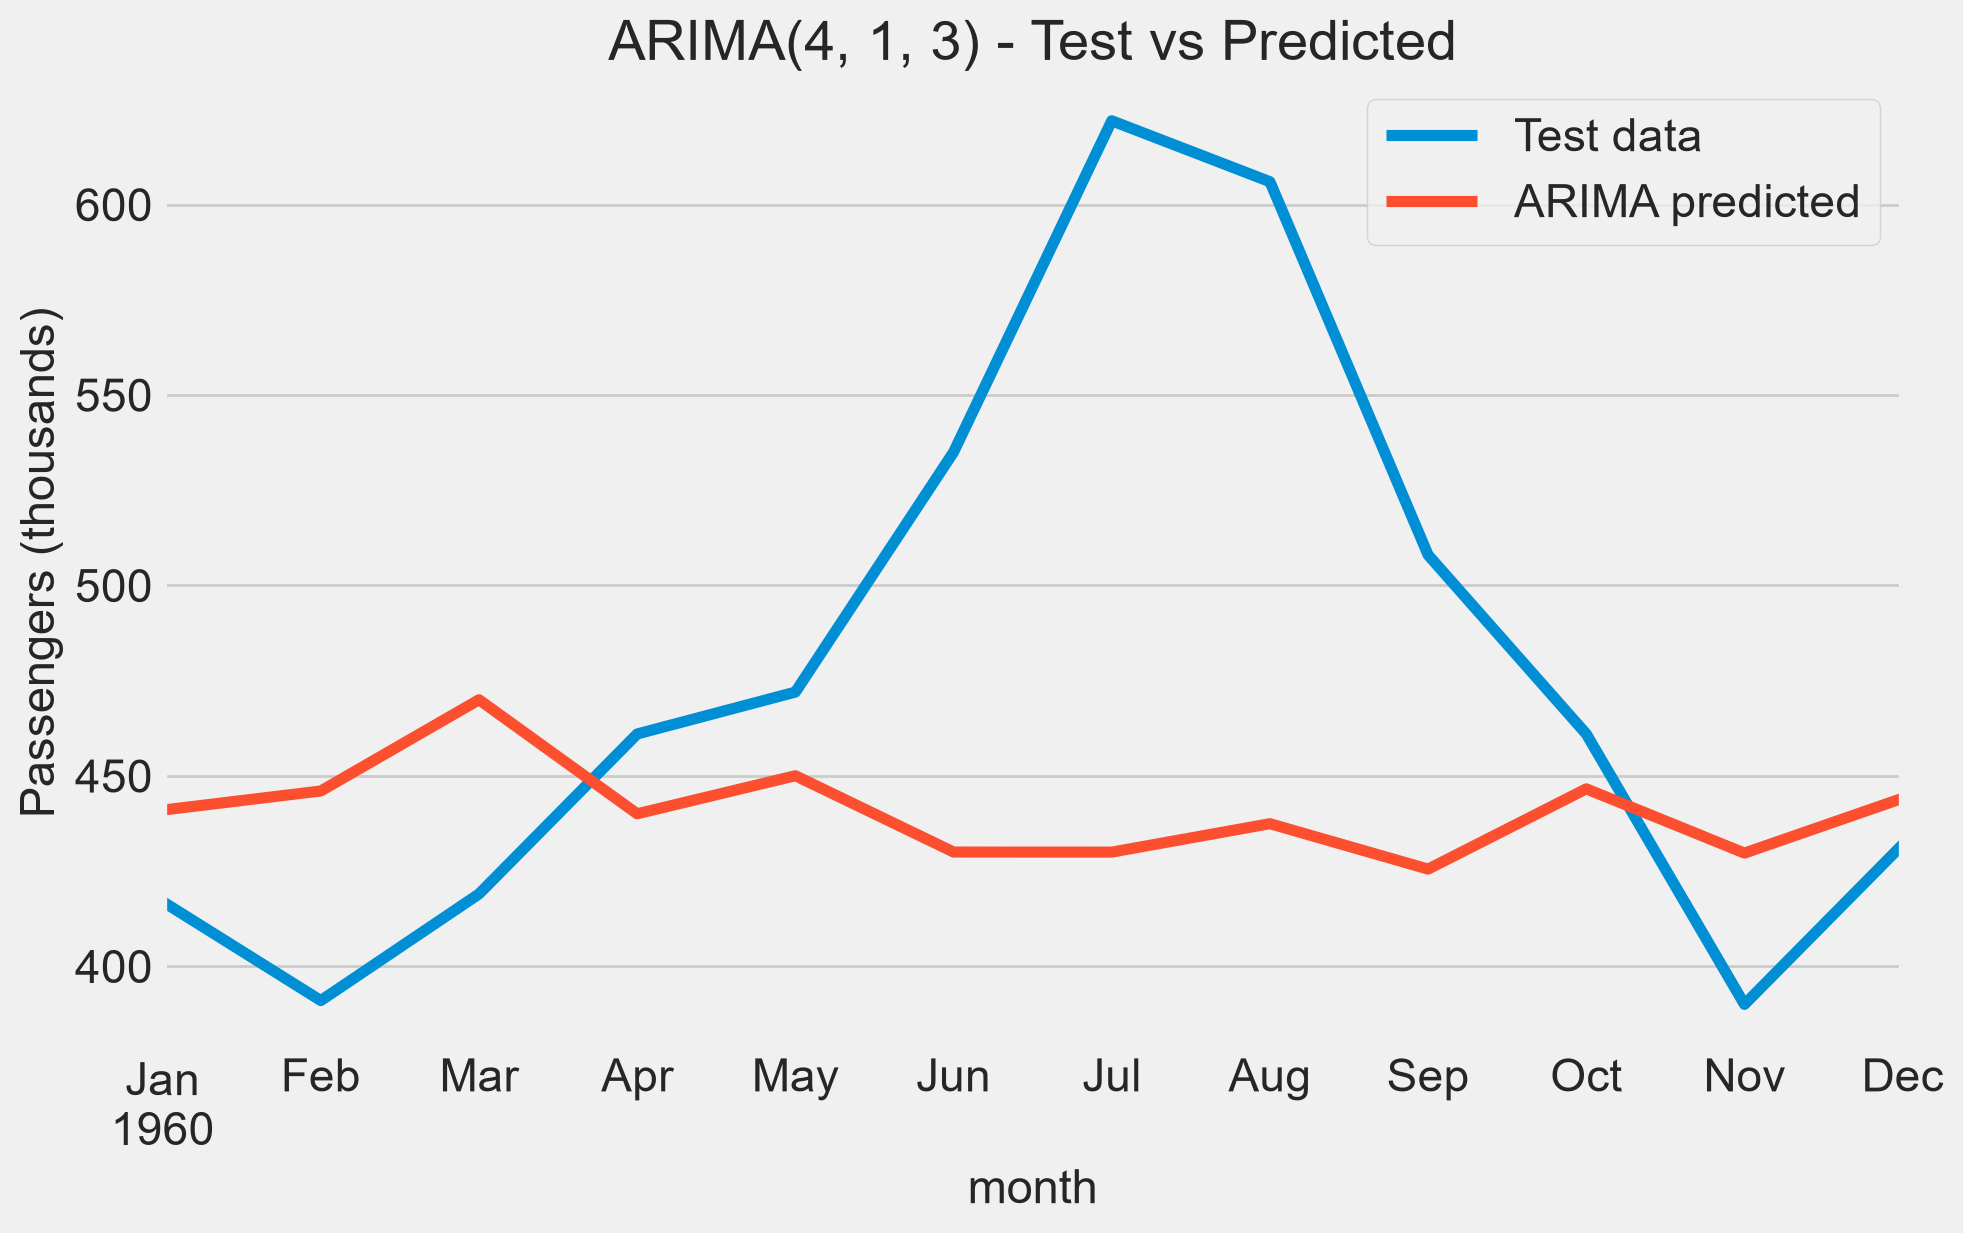

In [19]:
# Plot the test data vs predictions
title = f'ARIMA{arima_order} - Test vs Predicted'
ax = df_test['thousands_of_passengers'].plot(legend=True, figsize=(10, 6), title=title)
arima_predictions.plot(legend=True, ax=ax)
ax.set_ylabel('Passengers (thousands)')
ax.legend(['Test data', 'ARIMA predicted']);

### A8. Evaluate

Compute RMSE for the ARIMA model. Also print the mean of the series so you have something to compare the error against.

In [20]:
# Compute RMSE
arima_rmse = rmse(df_test['thousands_of_passengers'], arima_predictions)
print(f'ARIMA{arima_order} RMSE: {arima_rmse:.3f}')
print(f"Series mean: {df['thousands_of_passengers'].mean():.3f}")

ARIMA(4, 1, 3) RMSE: 87.640
Series mean: 280.299


---
# Part B - SARIMA

Now let's actually look at *why* the ARIMA forecast missed. This is where we introduce seasonality.


### B1. Seasonal decomposition

Run `seasonal_decompose` on the **original** (undifferenced) series and plot it.

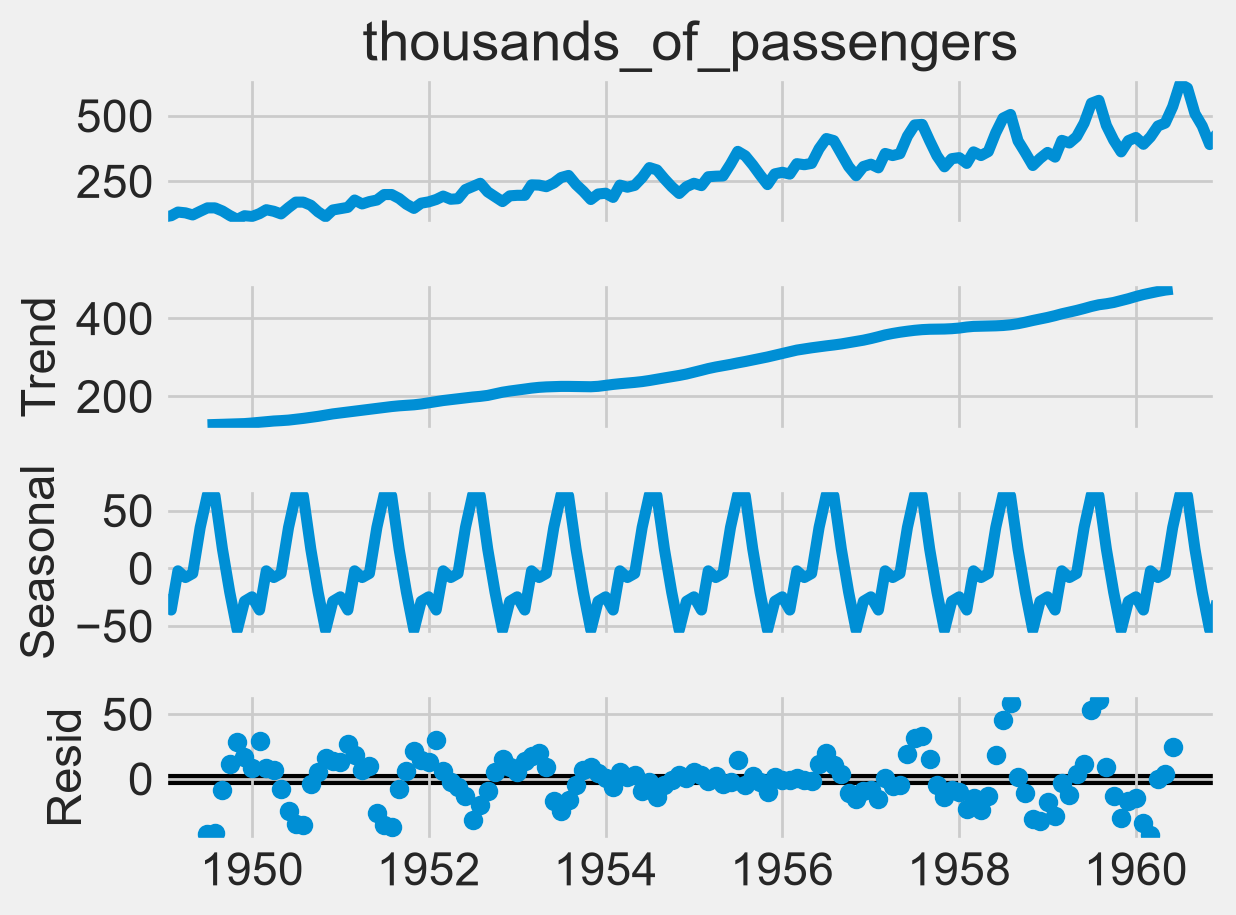

In [21]:
#YOUR CODE HERE
decomp = seasonal_decompose(df['thousands_of_passengers'], period=12)
decomp.plot()
plt.show()

**What do you see in the seasonal component?** Is there a repeating pattern? What's the period (how many months before it repeats)?

### B2. Search for a seasonal order with auto_arima

Run `auto_arima` again, this time with `seasonal=True` and `m=12` (12 months per cycle).

In [22]:
#YOUR CODE HERE
auto_fit_seasonal = auto_arima(df['thousands_of_passengers'],
                                start_p=0, start_q=0,
                                max_p=5, max_q=5,
                                seasonal=True,
                                m=12,
                                trace=True,
                                stepwise=True)
print(auto_fit_seasonal.order, auto_fit_seasonal.seasonal_order)
auto_fit_seasonal.summary()


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=1032.128, Time=0.20 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.14 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.05 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.25 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.59 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.30 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.18 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.34 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.46 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.26 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.11 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.23 sec
 ARIMA(0,1,1)(1,1,1)[12]     

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -505.589
Date:                             Thu, 13 Aug 2026   AIC                           1019.178
Time:                                     15:59:09   BIC                           1030.679
Sample:                                 01-01-1949   HQIC                          1023.851
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3634      0.074     -4.945      0.000      -0.508      -0.219
ar.S.L12      -0.1239      0.090     -1.372      0.170      -0.301       0.053
ar.S.L24       0.1911      0.107      1.783      0.075      -0.019       0.401
sigma2       130.4480     15.527      8.402      0.000     100.016     160.880
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 4.59
Prob(Q):                              0.92   Prob(JB):                         0.10
Heteroskedasticity (H):               2.70   Skew:                             0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.87
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Write down the order and seasonal_order suggested:**

- order (p,d,q) = 
- seasonal_order (P,D,Q,m) = 

### B3. Fit the SARIMA model

Use `SARIMAX` with both `order` and `seasonal_order`, fit on `df_train`.

In [23]:
#YOUR CODE HERE
sarima_order = auto_fit_seasonal.order
sarima_seasonal_order = auto_fit_seasonal.seasonal_order

sarima_model = SARIMAX(df_train['thousands_of_passengers'],
                        order=sarima_order,
                        seasonal_order=sarima_seasonal_order)
sarima_result = sarima_model.fit()
sarima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             thousands_of_passengers   No. Observations:                  132
Model:             SARIMAX(0, 1, 1)x(2, 1, [], 12)   Log Likelihood                -446.830
Date:                             Thu, 13 Aug 2026   AIC                            901.659
Time:                                     15:59:36   BIC                            912.776
Sample:                                 01-01-1949   HQIC                           906.173
                                      - 12-01-1959                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2556      0.080     -3.190      0.001      -0.413      -0.099
ar.S.L12      -0.0962      0.090     -1.073      0.283      -0.272       0.080
ar.S.L24       0.1454      0.101      1.445      0.149      -0.052       0.343
sigma2       106.2408     15.243      6.970      0.000      76.364     136.117
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 0.01
Prob(Q):                              0.86   Prob(JB):                         0.99
Heteroskedasticity (H):               1.63   Skew:                             0.01
Prob(H) (two-sided):                  0.12   Kurtosis:                         2.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### B4. Predict on the test set, with confidence intervals

This time, also pull the confidence interval so you can plot forecast uncertainty.

In [24]:
#YOUR CODE HERE
start = len(df_train)
end = len(df_train) + len(df_test) - 1

sarima_forecast = sarima_result.get_forecast(steps=len(df_test))
sarima_predictions = sarima_forecast.predicted_mean.rename('SARIMA Predictions')
sarima_ci = sarima_forecast.conf_int()

sarima_predictions


1960-01-01    421.153373
1960-02-01    401.605753
1960-03-01    462.083577
1960-04-01    450.826711
1960-05-01    475.124360
1960-06-01    529.774275
1960-07-01    605.741141
1960-08-01    618.774116
1960-09-01    516.769043
1960-10-01    463.571231
1960-11-01    417.168988
1960-12-01    458.049056
Freq: MS, Name: SARIMA Predictions, dtype: float64

### B5. Evaluate

In [25]:
# Compute RMSE
sarima_rmse = rmse(df_test['thousands_of_passengers'], sarima_predictions)
print(f'SARIMA{sarima_order}{sarima_seasonal_order} RMSE: {sarima_rmse:.3f}')

SARIMA(0, 1, 1)(2, 1, 0, 12) RMSE: 18.381


### B6. ARIMA vs. SARIMA

Plot both sets of predictions against the actual test values side by side and print both RMSEs together.

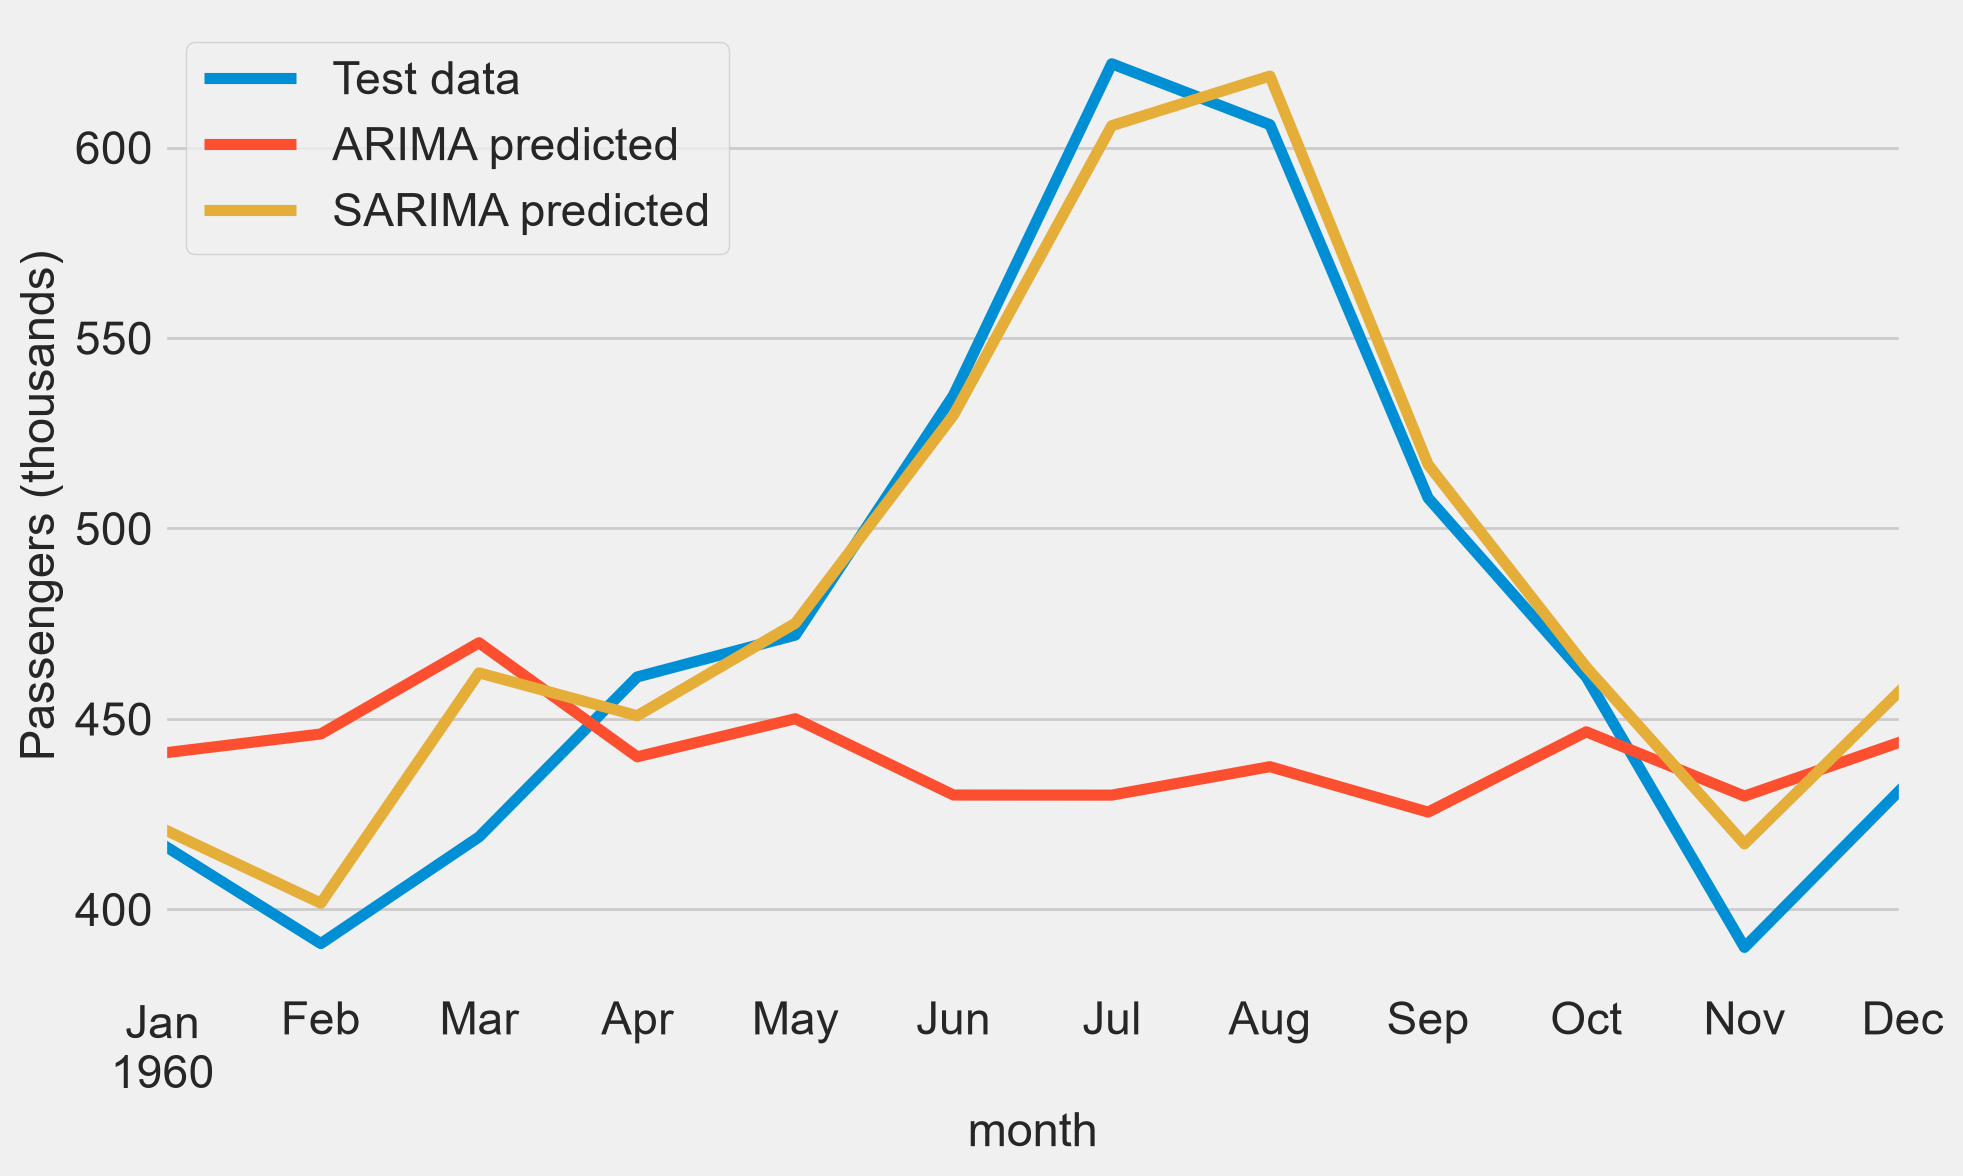

ARIMA(4, 1, 3) RMSE: 87.640
SARIMA(0, 1, 1)(2, 1, 0, 12) RMSE: 18.381


In [29]:
#YOUR CODE HERE
fig, ax = plt.subplots(figsize=(10, 6))
df_test['thousands_of_passengers'].plot(legend=True, ax=ax)
arima_predictions.plot(legend=True, ax=ax)
sarima_predictions.plot(legend=True, ax=ax)
ax.set_ylabel('Passengers (thousands)')
ax.legend(['Test data', 'ARIMA predicted', 'SARIMA predicted'])
plt.show()

print(f'ARIMA{arima_order} RMSE: {arima_rmse:.3f}')
print(f'SARIMA{sarima_order}{sarima_seasonal_order} RMSE: {sarima_rmse:.3f}')

<a id='forecast'></a>
## 2. Forecast the future

Retrain your **winning model** on the *full* dataset and forecast 12 months into the future

**Bonus**: *Plot the forecast with confidence intervals*.

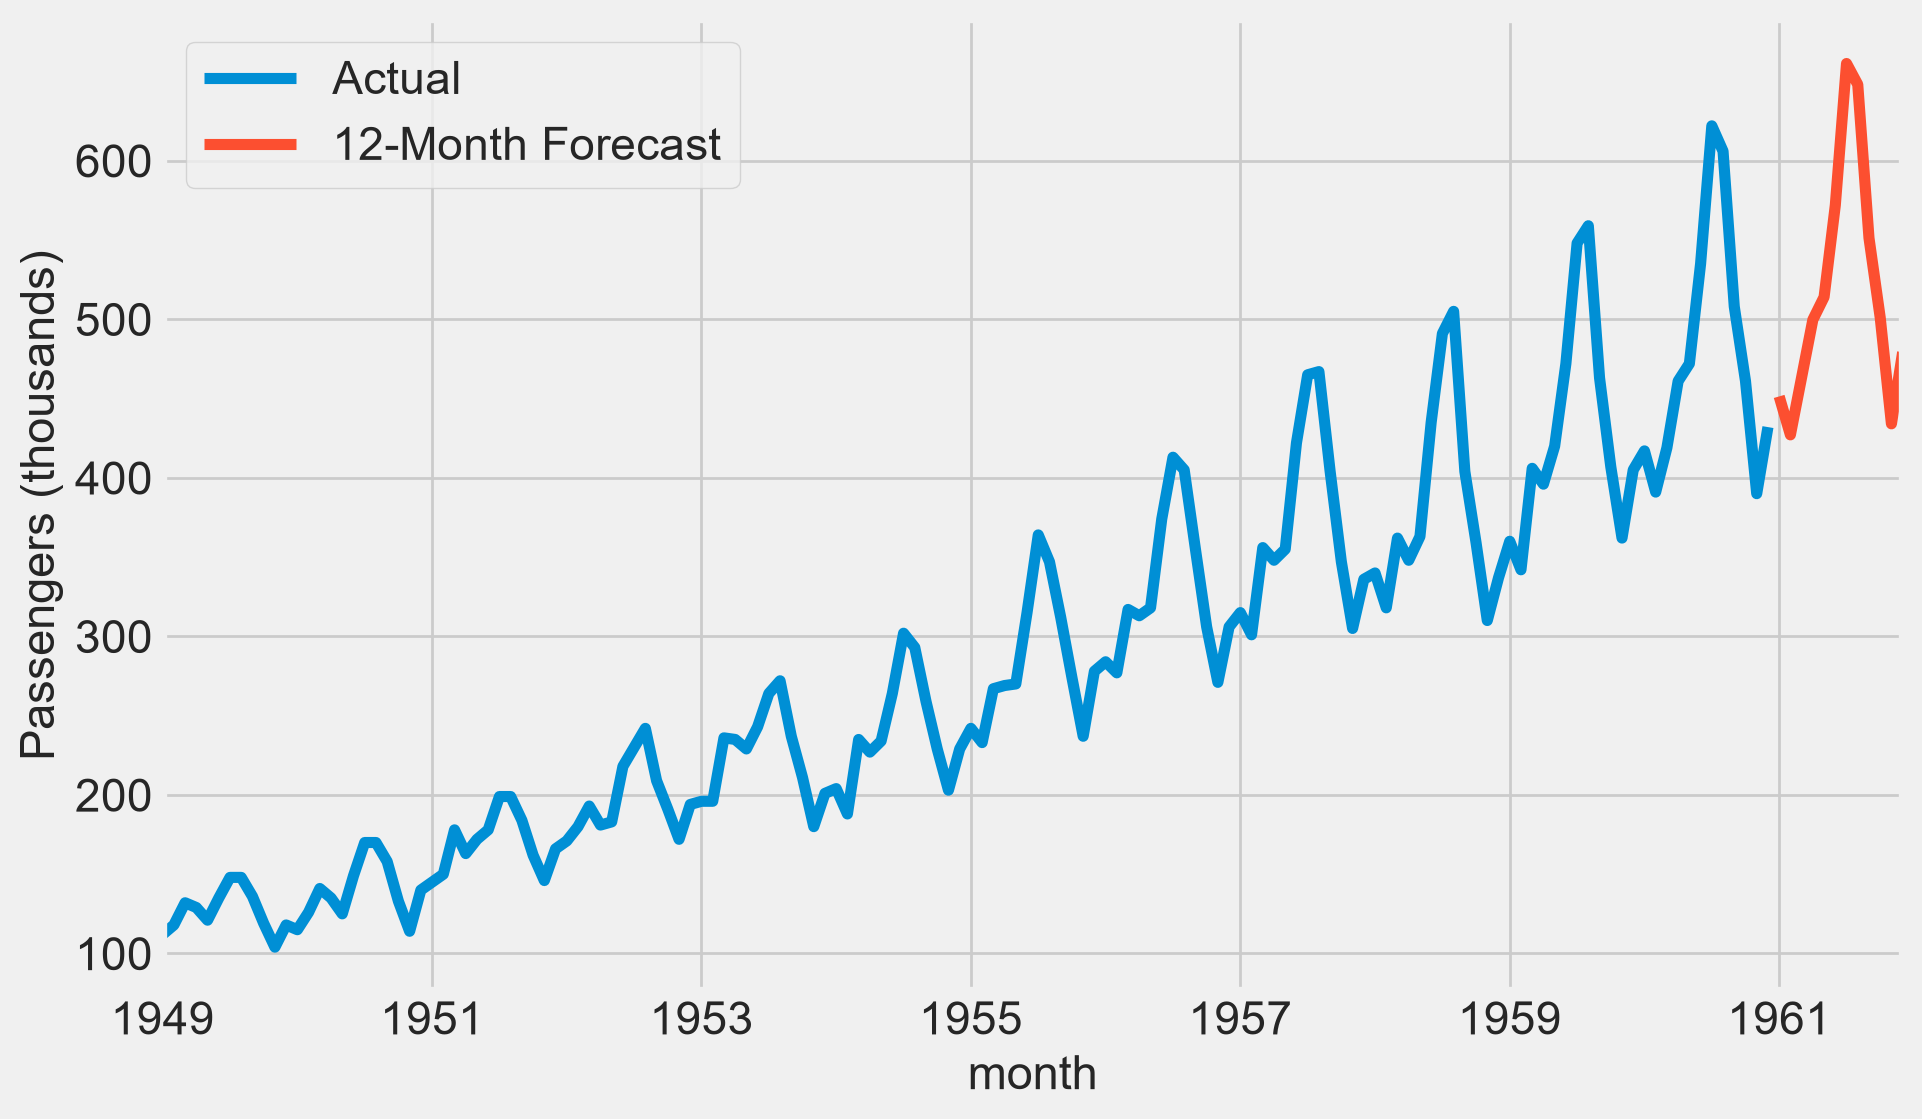

1961-01-01    451.347076
1961-02-01    427.102221
1961-03-01    463.382490
1961-04-01    499.705770
1961-05-01    514.035525
1961-06-01    571.851867
1961-07-01    661.310508
1961-08-01    648.081675
1961-09-01    551.284691
1961-10-01    501.068279
1961-11-01    434.052983
1961-12-01    479.233767
Freq: MS, Name: Forecast, dtype: float64

In [31]:
#YOUR CODE HERE
final_model = SARIMAX(df['thousands_of_passengers'],
                       order=sarima_order,
                       seasonal_order=sarima_seasonal_order)
final_result = final_model.fit()

final_forecast = final_result.get_forecast(steps=12)
future_predictions = final_forecast.predicted_mean.rename('Forecast')
future_ci = final_forecast.conf_int()

fig, ax = plt.subplots(figsize=(10, 6))
df['thousands_of_passengers'].plot(legend=True, ax=ax)
future_predictions.plot(legend=True, ax=ax)
ax.set_ylabel('Passengers (thousands)')
ax.legend(['Actual', '12-Month Forecast'])
plt.show()

future_predictions

## Takeaways
- Seasonality is easy to miss if you don't plot/decompose the data, hence, always look before you model.
- SARIMA isn't automatically the right call; it's justified when the seasonal component is real and the added parameters actually reduce error on held-out data.
- Always evaluate on a proper time-ordered train,test, and split.


## Additional Resources
- [statsmodels SARIMAX documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)
- [pmdarima auto_arima documentation](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html)
- [Forecasting: Principles and Practice - Seasonal ARIMA](https://otexts.com/fpp2/seasonal-arima.html)
